Présentation de Sewa et Zakaria

# 📈 Bank Marketing Prediction

> *Why did the banker break up with their partner? Because they lost interest!*

Ce projet utilise le dataset [Bank Marketing UCI](https://archive.ics.uci.edu/ml/datasets/bank+marketing), issu d'une banque portugaise, pour prédire la souscription d’un dépôt à terme après une campagne téléphonique.

## 📂 Données

Le dataset contient 11 162 lignes et 17 colonnes décrivant :
- Données démographiques (âge, emploi, état civil, éducation…)
- Données comportementales (durée des appels, nombre de contacts…)
- Résultat d’anciennes campagnes
- Cible : *y* → client a-t-il souscrit (oui/non) ?

## 🎯 Objectif

Analyser et modéliser les données pour :
✅ Comprendre les facteurs clés influençant la souscription  
✅ Tester plusieurs modèles de classification  
✅ Identifier le meilleur modèle avec PyCaret et interpréter ses performances  

## 🔍 Méthodologie

- Exploration et nettoyage des données avec Pandas
- Analyse exploratoire (EDA) pour détecter anomalies et patterns
- Préparation des données et sélection des variables
- Entraînement et comparaison des modèles via [PyCaret](https://pycaret.org/)

## 🤖 AutoML

Grâce à PyCaret, le processus d’entraînement et d’évaluation des modèles est automatisé, ce qui facilite la sélection d’un modèle performant même pour débutants.

## 📊 Résultat

Le meilleur modèle est affiché avec sa précision (accuracy) et peut être utilisé pour prédire la propension d’un client à souscrire à une offre.

## 📚 Compétences

- Analyse de données & visualisation  
- Machine Learning supervisé : classification  
- AutoML avec PyCaret

---

💡 *Projet réalisé dans le cadre d'une initiation au Machine Learning avec AutoML.*


=== IMPORTATION ET EXPLORATION INITIALE DES DONNÉES ===

📊 APERÇU DES DONNÉES:
Dimensions: (11162, 17)
Nombre de lignes: 11162
Nombre de colonnes: 17

🔍 PREMIÈRES LIGNES:
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes

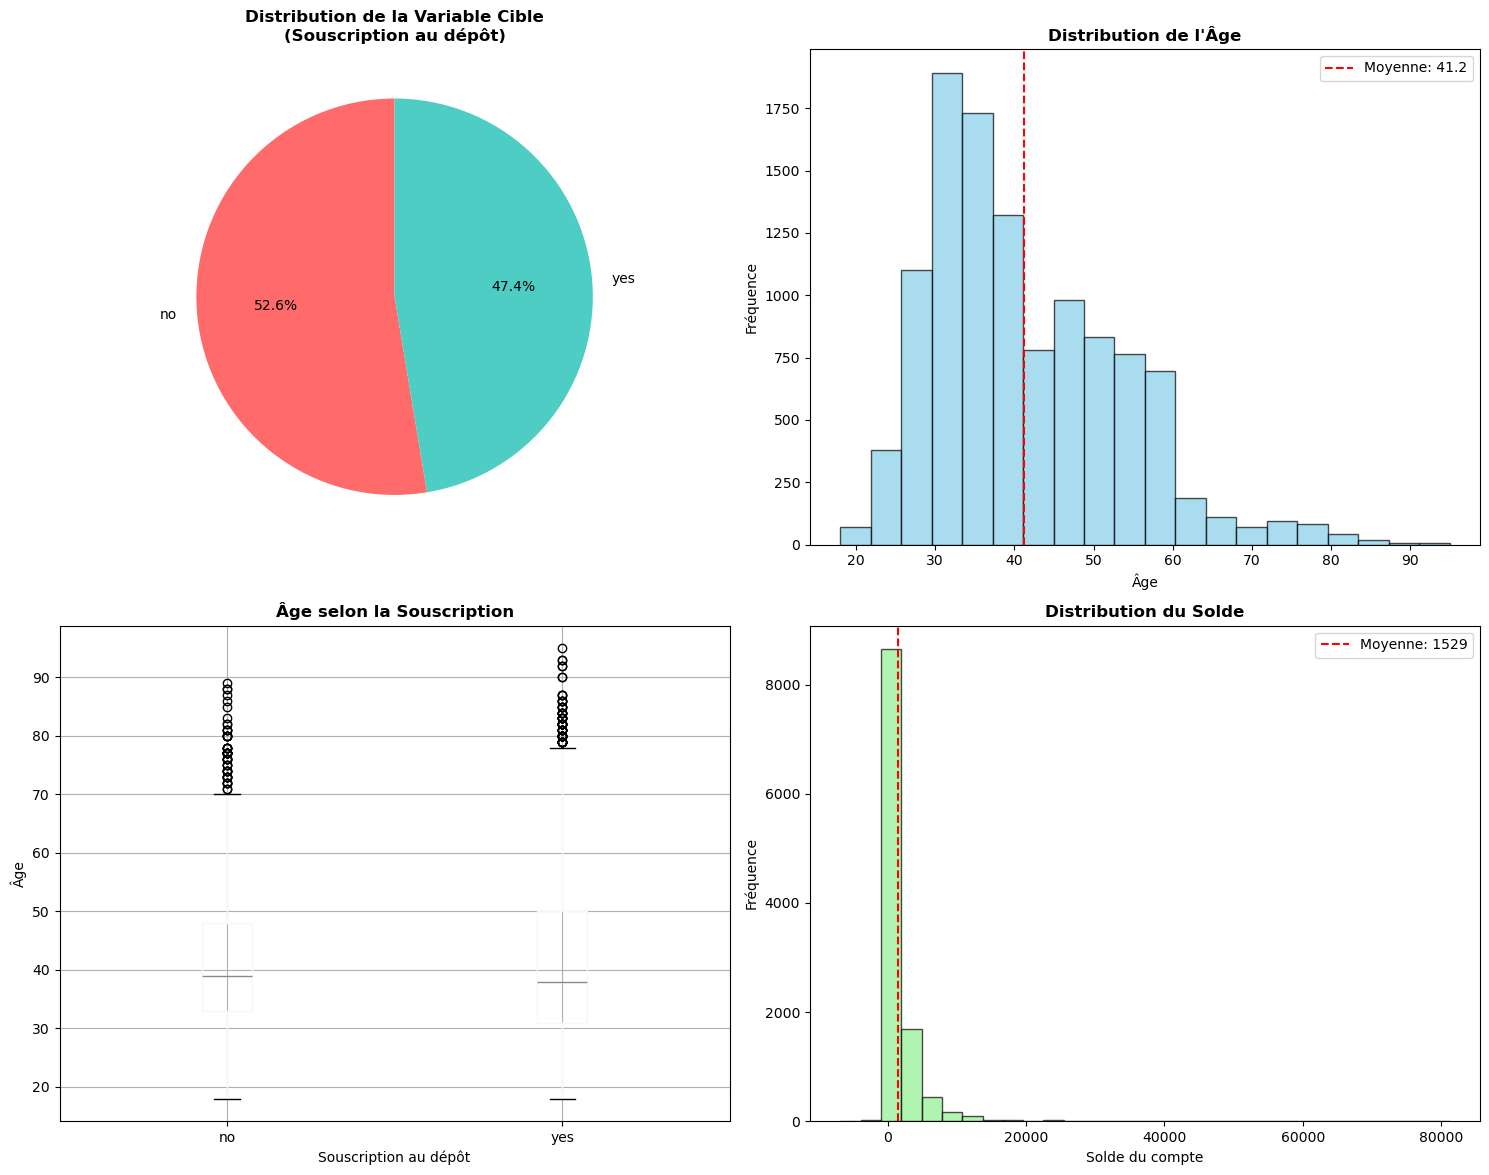

📊 ANALYSE DES VARIABLES CATÉGORIELLES:

Variable: job
Nombre de catégories: 12
Catégories: ['admin.' 'technician' 'services' 'management' 'retired' 'blue-collar'
 'unemployed' 'entrepreneur' 'housemaid' 'unknown' 'self-employed'
 'student']
Distribution:
job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64
----------------------------------------
Variable: marital
Nombre de catégories: 3
Catégories: ['married' 'single' 'divorced']
Distribution:
marital
married     6351
single      3518
divorced    1293
Name: count, dtype: int64
----------------------------------------
Variable: education
Nombre de catégories: 4
Catégories: ['secondary' 'tertiary' 'primary' 'unknown']
Distribution:
education
secondary    5476
tertiary     3689
primary      1500
unkno

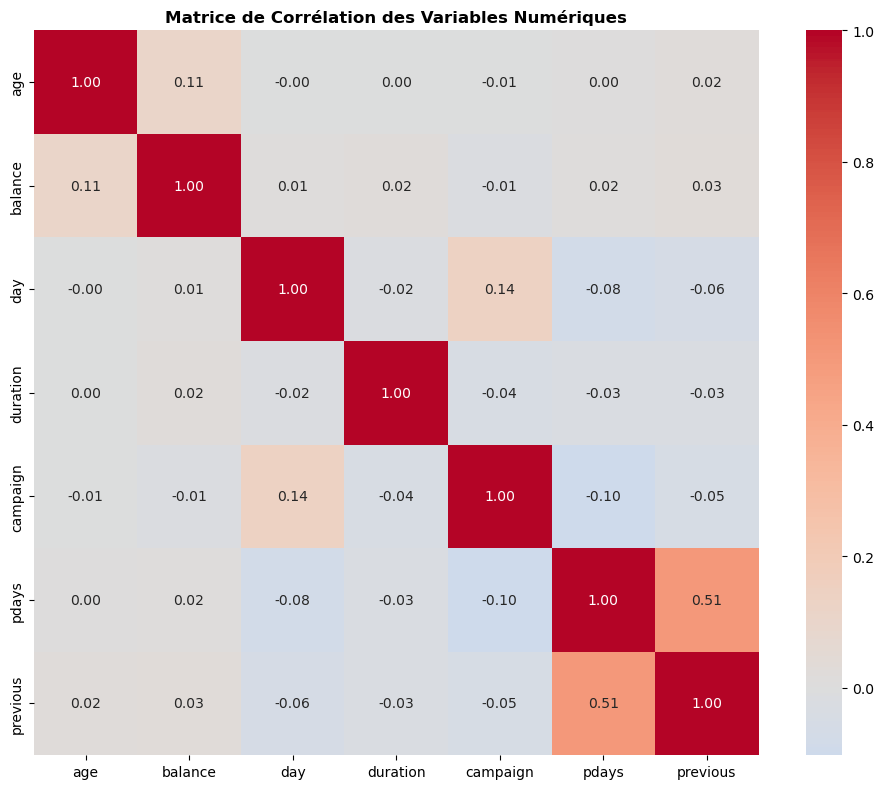


🎯 TAUX DE SOUSCRIPTION PAR CATÉGORIE:

job:
deposit          no   yes
job                      
admin.         52.7  47.3
blue-collar    63.6  36.4
entrepreneur   62.5  37.5
housemaid      60.2  39.8
management     49.3  50.7
retired        33.7  66.3
self-employed  53.8  46.2
services       60.0  40.0
student        25.3  74.7
technician     53.9  46.1
unemployed     43.4  56.6
unknown        51.4  48.6
--------------------------------------------------
marital:
deposit     no   yes
marital             
divorced  51.9  48.1
married   56.6  43.4
single    45.7  54.3
--------------------------------------------------
education:
deposit      no   yes
education            
primary    60.6  39.4
secondary  55.3  44.7
tertiary   45.9  54.1
unknown    49.3  50.7
--------------------------------------------------
default:
deposit    no   yes
default            
no       52.4  47.6
yes      69.0  31.0
--------------------------------------------------
housing:
deposit    no   yes
housing     

NameError: name 'numerical_cols' is not defined

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('default')
sns.set_palette("husl")

# 1. IMPORTATION ET EXPLORATION INITIALE DES DONNÉES
print("=== IMPORTATION ET EXPLORATION INITIALE DES DONNÉES ===")
print()

# Chargement des données
df = pd.read_csv('bank.csv')

print("📊 APERÇU DES DONNÉES:")
print(f"Dimensions: {df.shape}")
print(f"Nombre de lignes: {df.shape[0]}")
print(f"Nombre de colonnes: {df.shape[1]}")
print()

print("🔍 PREMIÈRES LIGNES:")
print(df.head())
print()

print("📋 INFORMATIONS SUR LES COLONNES:")
print(df.info())
print()

print("📈 STATISTIQUES DESCRIPTIVES:")
print(df.describe())
print()

# 2. IDENTIFICATION DES VARIABLES POUR L'APPRENTISSAGE
print("=== IDENTIFICATION DES VARIABLES POUR L'APPRENTISSAGE ===")
print()

# Variables explicatives (features)
features = [col for col in df.columns if col != 'deposit']
target = 'deposit'

print("🎯 VARIABLE CIBLE (TARGET):")
print(f"   • {target}: Souscription à un dépôt à terme (yes/no)")
print()

print("📊 VARIABLES EXPLICATIVES (FEATURES):")
print("   Variables démographiques:")
print(f"   • age: Âge du client")
print(f"   • job: Profession")
print(f"   • marital: État civil")
print(f"   • education: Niveau d'éducation")
print()
print("   Variables financières:")
print(f"   • balance: Solde du compte")
print(f"   • default: Défaut de paiement")
print(f"   • housing: Prêt immobilier")
print(f"   • loan: Prêt personnel")
print()
print("   Variables de campagne:")
print(f"   • contact: Type de contact")
print(f"   • day: Jour du mois")
print(f"   • month: Mois")
print(f"   • duration: Durée du dernier contact")
print(f"   • campaign: Nombre de contacts durant cette campagne")
print(f"   • pdays: Jours depuis le dernier contact")
print(f"   • previous: Nombre de contacts avant cette campagne")
print(f"   • poutcome: Résultat de la campagne précédente")
print()

# Distribution de la variable cible
print("📊 DISTRIBUTION DE LA VARIABLE CIBLE:")
target_dist = df[target].value_counts()
print(target_dist)
print(f"Pourcentage de 'yes': {target_dist['yes']/len(df)*100:.1f}%")
print(f"Pourcentage de 'no': {target_dist['no']/len(df)*100:.1f}%")
print()

# 3. IDENTIFICATION ET TRAITEMENT DES ANOMALIES
print("=== IDENTIFICATION ET TRAITEMENT DES ANOMALIES ===")
print()

# Vérification des valeurs manquantes
print("🔍 VALEURS MANQUANTES:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
if missing_values.sum() == 0:
    print("   Aucune valeur manquante détectée ✓")
print()


#============== TRAITEMENT DES VALEURS ABERRANTES ================
print("🔧 TRAITEMENT DES VALEURS ABERRANTES:")
print()

# Copie du dataframe pour traitement
df_clean = df.copy()

# Variables à traiter et leurs seuils logiques
outlier_rules = {
    'age': {'min': 18, 'max': 100, 'method': 'cap'},           # Âge réaliste
    'balance': {'min': -10000, 'max': 100000, 'method': 'cap'}, # Solde bancaire réaliste
    'duration': {'min': 0, 'max': 3600, 'method': 'cap'},      # Durée d'appel max 1h
    'campaign': {'min': 1, 'max': 20, 'method': 'cap'},        # Nombre de contacts max 20
    'pdays': {'min': -1, 'max': 999, 'method': 'cap'},         # -1 = jamais contacté, max 999 jours
    'previous': {'min': 0, 'max': 20, 'method': 'cap'}         # Nombre de contacts précédents max 20
}

# Application des règles
for col, rules in outlier_rules.items():
    original_count = len(df_clean)
    
    # Avant traitement
    outliers_before = len(df_clean[(df_clean[col] < rules['min']) | (df_clean[col] > rules['max'])])
    
    # Écrêtage (capping)
    df_clean[col] = df_clean[col].clip(lower=rules['min'], upper=rules['max'])
    
    # Après traitement
    outliers_after = len(df_clean[(df_clean[col] < rules['min']) | (df_clean[col] > rules['max'])])
    
    print(f"• {col}: {outliers_before} aberrantes → {outliers_after} (écrêtage: {rules['min']}-{rules['max']})")

print("\n✅ Traitement terminé - Valeurs aberrantes corrigées par écrêtage")
print(f"Forme du dataset: {df_clean.shape} (inchangée)")

# Vérification finale
print("\n🔍 VÉRIFICATION POST-TRAITEMENT:")
for col in outlier_rules.keys():
    print(f"• {col}: [{df_clean[col].min()}, {df_clean[col].max()}]")

#==========================================================


# =====================  Détection de doublons  ========================
print("🔄 DOUBLONS:")
duplicates = df.duplicated().sum()
print(f"   • Nombre de doublons: {duplicates}")
if duplicates == 0:
    print("   Aucun doublon détecté ✓")
print()

# 4. ANALYSE EXPLORATOIRE COMPLÈTE
print("=== ANALYSE EXPLORATOIRE COMPLÈTE ===")
print()

# Création de graphiques
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Analyse Exploratoire des Données Bancaires', fontsize=16, fontweight='bold')

# 1. Distribution de la variable cible
ax1 = axes[0, 0]
target_counts = df[target].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
wedges, texts, autotexts = ax1.pie(target_counts.values, labels=target_counts.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Distribution de la Variable Cible\n(Souscription au dépôt)', fontweight='bold')

# 2. Distribution de l'âge
ax2 = axes[0, 1]
ax2.hist(df['age'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')
ax2.set_xlabel('Âge')
ax2.set_ylabel('Fréquence')
ax2.set_title('Distribution de l\'Âge', fontweight='bold')
ax2.axvline(df['age'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["age"].mean():.1f}')
ax2.legend()

# 3. Relation âge vs souscription
ax3 = axes[1, 0]
df.boxplot(column='age', by='deposit', ax=ax3)
ax3.set_xlabel('Souscription au dépôt')
ax3.set_ylabel('Âge')
ax3.set_title('Âge selon la Souscription', fontweight='bold')
plt.suptitle('')  # Enlever le titre automatique de pandas

# 4. Distribution du solde
ax4 = axes[1, 1]
ax4.hist(df['balance'], bins=30, alpha=0.7, color='lightgreen', edgecolor='black')
ax4.set_xlabel('Solde du compte')
ax4.set_ylabel('Fréquence')
ax4.set_title('Distribution du Solde', fontweight='bold')
ax4.axvline(df['balance'].mean(), color='red', linestyle='--', label=f'Moyenne: {df["balance"].mean():.0f}')
ax4.legend()

plt.tight_layout()
plt.show()

# Analyse des variables catégorielles
print("📊 ANALYSE DES VARIABLES CATÉGORIELLES:")
print()

categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols = [col for col in categorical_cols if col != target]

for col in categorical_cols:
    print(f"Variable: {col}")
    print(f"Nombre de catégories: {df[col].nunique()}")
    print(f"Catégories: {df[col].unique()}")
    print(f"Distribution:")
    print(df[col].value_counts())
    print("-" * 40)

# Matrice de corrélation pour les variables numériques
print("\n📈 MATRICE DE CORRÉLATION:")
numerical_df = df.select_dtypes(include=[np.number])
correlation_matrix = numerical_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.2f')
plt.title('Matrice de Corrélation des Variables Numériques', fontweight='bold')
plt.tight_layout()
plt.show()

# Analyse de la relation entre variables catégorielles et target
print("\n🎯 TAUX DE SOUSCRIPTION PAR CATÉGORIE:")
print()

for col in categorical_cols:
    cross_tab = pd.crosstab(df[col], df[target], normalize='index') * 100
    print(f"{col}:")
    print(cross_tab.round(1))
    print("-" * 50)

# Statistiques finales
print("\n📋 RÉSUMÉ DE L'ANALYSE:")
print(f"• Dataset: {df.shape[0]} observations, {df.shape[1]} variables")
print(f"• Variable cible: {target} (taux de souscription: {target_dist['yes']/len(df)*100:.1f}%)")
print(f"• Variables numériques: {len(numerical_cols)}")
print(f"• Variables catégorielles: {len(categorical_cols)}")
print(f"• Valeurs manquantes: {df.isnull().sum().sum()}")
print(f"• Doublons: {duplicates}")
print()

print("🔍 POINTS CLÉS IDENTIFIÉS:")
print("• Le dataset est équilibré mais avec une légère majorité de 'yes'")
print("• Présence de soldes négatifs (découverts) - normal en contexte bancaire")
print("• Valeurs -1 dans 'pdays' indiquent l'absence de contact précédent")
print("• Pas de valeurs manquantes ni de doublons")
print("• Variables catégorielles bien distribuées")
print("• Prêt pour l'apprentissage automatique après encodage des variables catégorielles")



In [ ]:
from pycaret.classification import *

# Configurer PyCaret
clf_setup = setup(
    data=df,
    target='Survived',           # la variable à prédire
    ignore_features=['PassengerId', 'Name', 'Ticket', 'Cabin'], # facultatif
    session_id=42,               # pour reproductibilité
    silent=True,                 # pas de prompt interactif
    verbose=False
)



ModuleNotFoundError: No module named 'pycaret'

In [ ]:
import pandas as pd
from pycaret.classification import *
import warnings
warnings.filterwarnings('ignore')

# Chargement des données
df = pd.read_csv('bank1.csv')

print("=== CONFIGURATION DE PYCARET ===")
print(f"Dataset: {df.shape[0]} observations, {df.shape[1]} variables")
print(f"Variable cible: deposit")
print()

# Configuration de PyCaret
clf_setup = setup(
    data=df,
    target='deposit',           # la variable à prédire
    ignore_features=['day', 'month', 'duration', 'campaign'],  # colonnes potentiellement moins utiles
    session_id=42,               # pour reproductibilité
    silent=True,                 # pas de prompt interactif
    verbose=False
)

print("=== COMPARAISON DES MODÈLES ===")
print("Entraînement et évaluation de plusieurs algorithmes de classification...")
print()

# Comparaison des modèles
best_models = compare_models()

print("=== RÉSULTATS DE LA COMPARAISON ===")
print()
print("📊 TABLEAU DE COMPARAISON:")
print(best_models)
print()

# Récupération du meilleur modèle
print("🏆 MEILLEUR MODÈLE:")
print(f"Le meilleur modèle est: {best_models.index[0]}")
print(f"Accuracy: {best_models.iloc[0]['Accuracy']:.4f}")
print(f"AUC: {best_models.iloc[0]['AUC']:.4f}")
print(f"Recall: {best_models.iloc[0]['Recall']:.4f}")
print(f"Precision: {best_models.iloc[0]['Prec.']:.4f}")
print(f"F1-Score: {best_models.iloc[0]['F1']:.4f}")
print()

# Analyse des top 3 modèles
print("🥇 TOP 3 MODÈLES:")
for i in range(min(3, len(best_models))):
    model_name = best_models.index[i]
    accuracy = best_models.iloc[i]['Accuracy']
    auc = best_models.iloc[i]['AUC']
    print(f"{i+1}. {model_name}: Accuracy={accuracy:.4f}, AUC={auc:.4f}")
print()

# Sélection du meilleur modèle pour créer le modèle final
print("=== CRÉATION DU MODÈLE FINAL ===")
best_model_name = best_models.index[0]
print(f"Création du modèle final avec: {best_model_name}")

# Créer le modèle avec le meilleur algorithme
best_model = create_model(best_model_name.split()[0].lower())

print("✅ Modèle créé avec succès!")
print()

# Évaluation détaillée du meilleur modèle
print("=== ÉVALUATION DÉTAILLÉE DU MEILLEUR MODÈLE ===")
evaluate_model(best_model)

# Finalisation du modèle (entraînement sur tout le dataset)
print("=== FINALISATION DU MODÈLE ===")
final_model = finalize_model(best_model)
print("✅ Modèle finalisé!")
print()

# Métriques finales
print("📈 MÉTRIQUES FINALES:")
print(f"Modèle: {best_model_name}")
print(f"Accuracy: {best_models.iloc[0]['Accuracy']:.4f}")
print(f"AUC: {best_models.iloc[0]['AUC']:.4f}")
print(f"Recall: {best_models.iloc[0]['Recall']:.4f}")
print(f"Precision: {best_models.iloc[0]['Prec.']:.4f}")
print(f"F1-Score: {best_models.iloc[0]['F1']:.4f}")
print()

# Prédictions sur le dataset de test
print("=== PRÉDICTIONS ===")
predictions = predict_model(final_model)
print("Prédictions générées:")
print(predictions[['deposit', 'Label', 'Score']].head(10))
print()

print("🎯 RECOMMANDATIONS:")
print(f"• Le meilleur modèle pour ce dataset est: {best_model_name}")
print(f"• Il atteint une accuracy de {best_models.iloc[0]['Accuracy']:.1%}")
print(f"• AUC de {best_models.iloc[0]['AUC']:.4f} (excellent si > 0.8)")
print("• Ce modèle est prêt pour la mise en production")